In [5]:
# --- Bootstrap: make the repository packages importable without installation ---
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)

import time
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring.io import load_observables, load_run

plot.apply_style(plot.PAPER_STYLE)


repo root: /Users/jzuluaga/dev/PRisma


In [6]:
SYSTEM = "kepler51"
CASE = "kepler_51"
PLANET = "d"

# The data was generated using the sweep script in dev/
# which wrote to dev/kepler_51/results/
DEV_RESULTS_DIR = _REPO / "dev" / CASE / "results"

paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
ttv = load_observables(paths.observables_file(PLANET))


In [7]:
# The run tags generated by the sweep for our specific config
tag_exo = "kepler_51_d_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE"
tag_geo = "kepler_51_d_NS_geotrans_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE"

run_exo = load_run(DEV_RESULTS_DIR / "exorings" / f"{tag_exo}.npz")
run_geo = load_run(DEV_RESULTS_DIR / "geotrans" / f"{tag_geo}.npz")

# Extract the times from metadata
t_exo = run_exo['runtime_s']
t_geo = run_geo['runtime_s']

print("=========================================")
print("=== PERFORMANCE COMPARISON ===")
print("=========================================")
print(f"Time for exorings: {t_exo/3600:.2f} hours")
print(f"Time for geotrans: {t_geo/3600:.2f} hours")
print(f"Geotrans is {t_geo / t_exo:.2f}x the time of exorings.")


=== PERFORMANCE COMPARISON ===
Time for exorings: 0.03 hours
Time for geotrans: 0.11 hours
Geotrans is 4.12x the time of exorings.


--- Corner Plot for Exorings ---


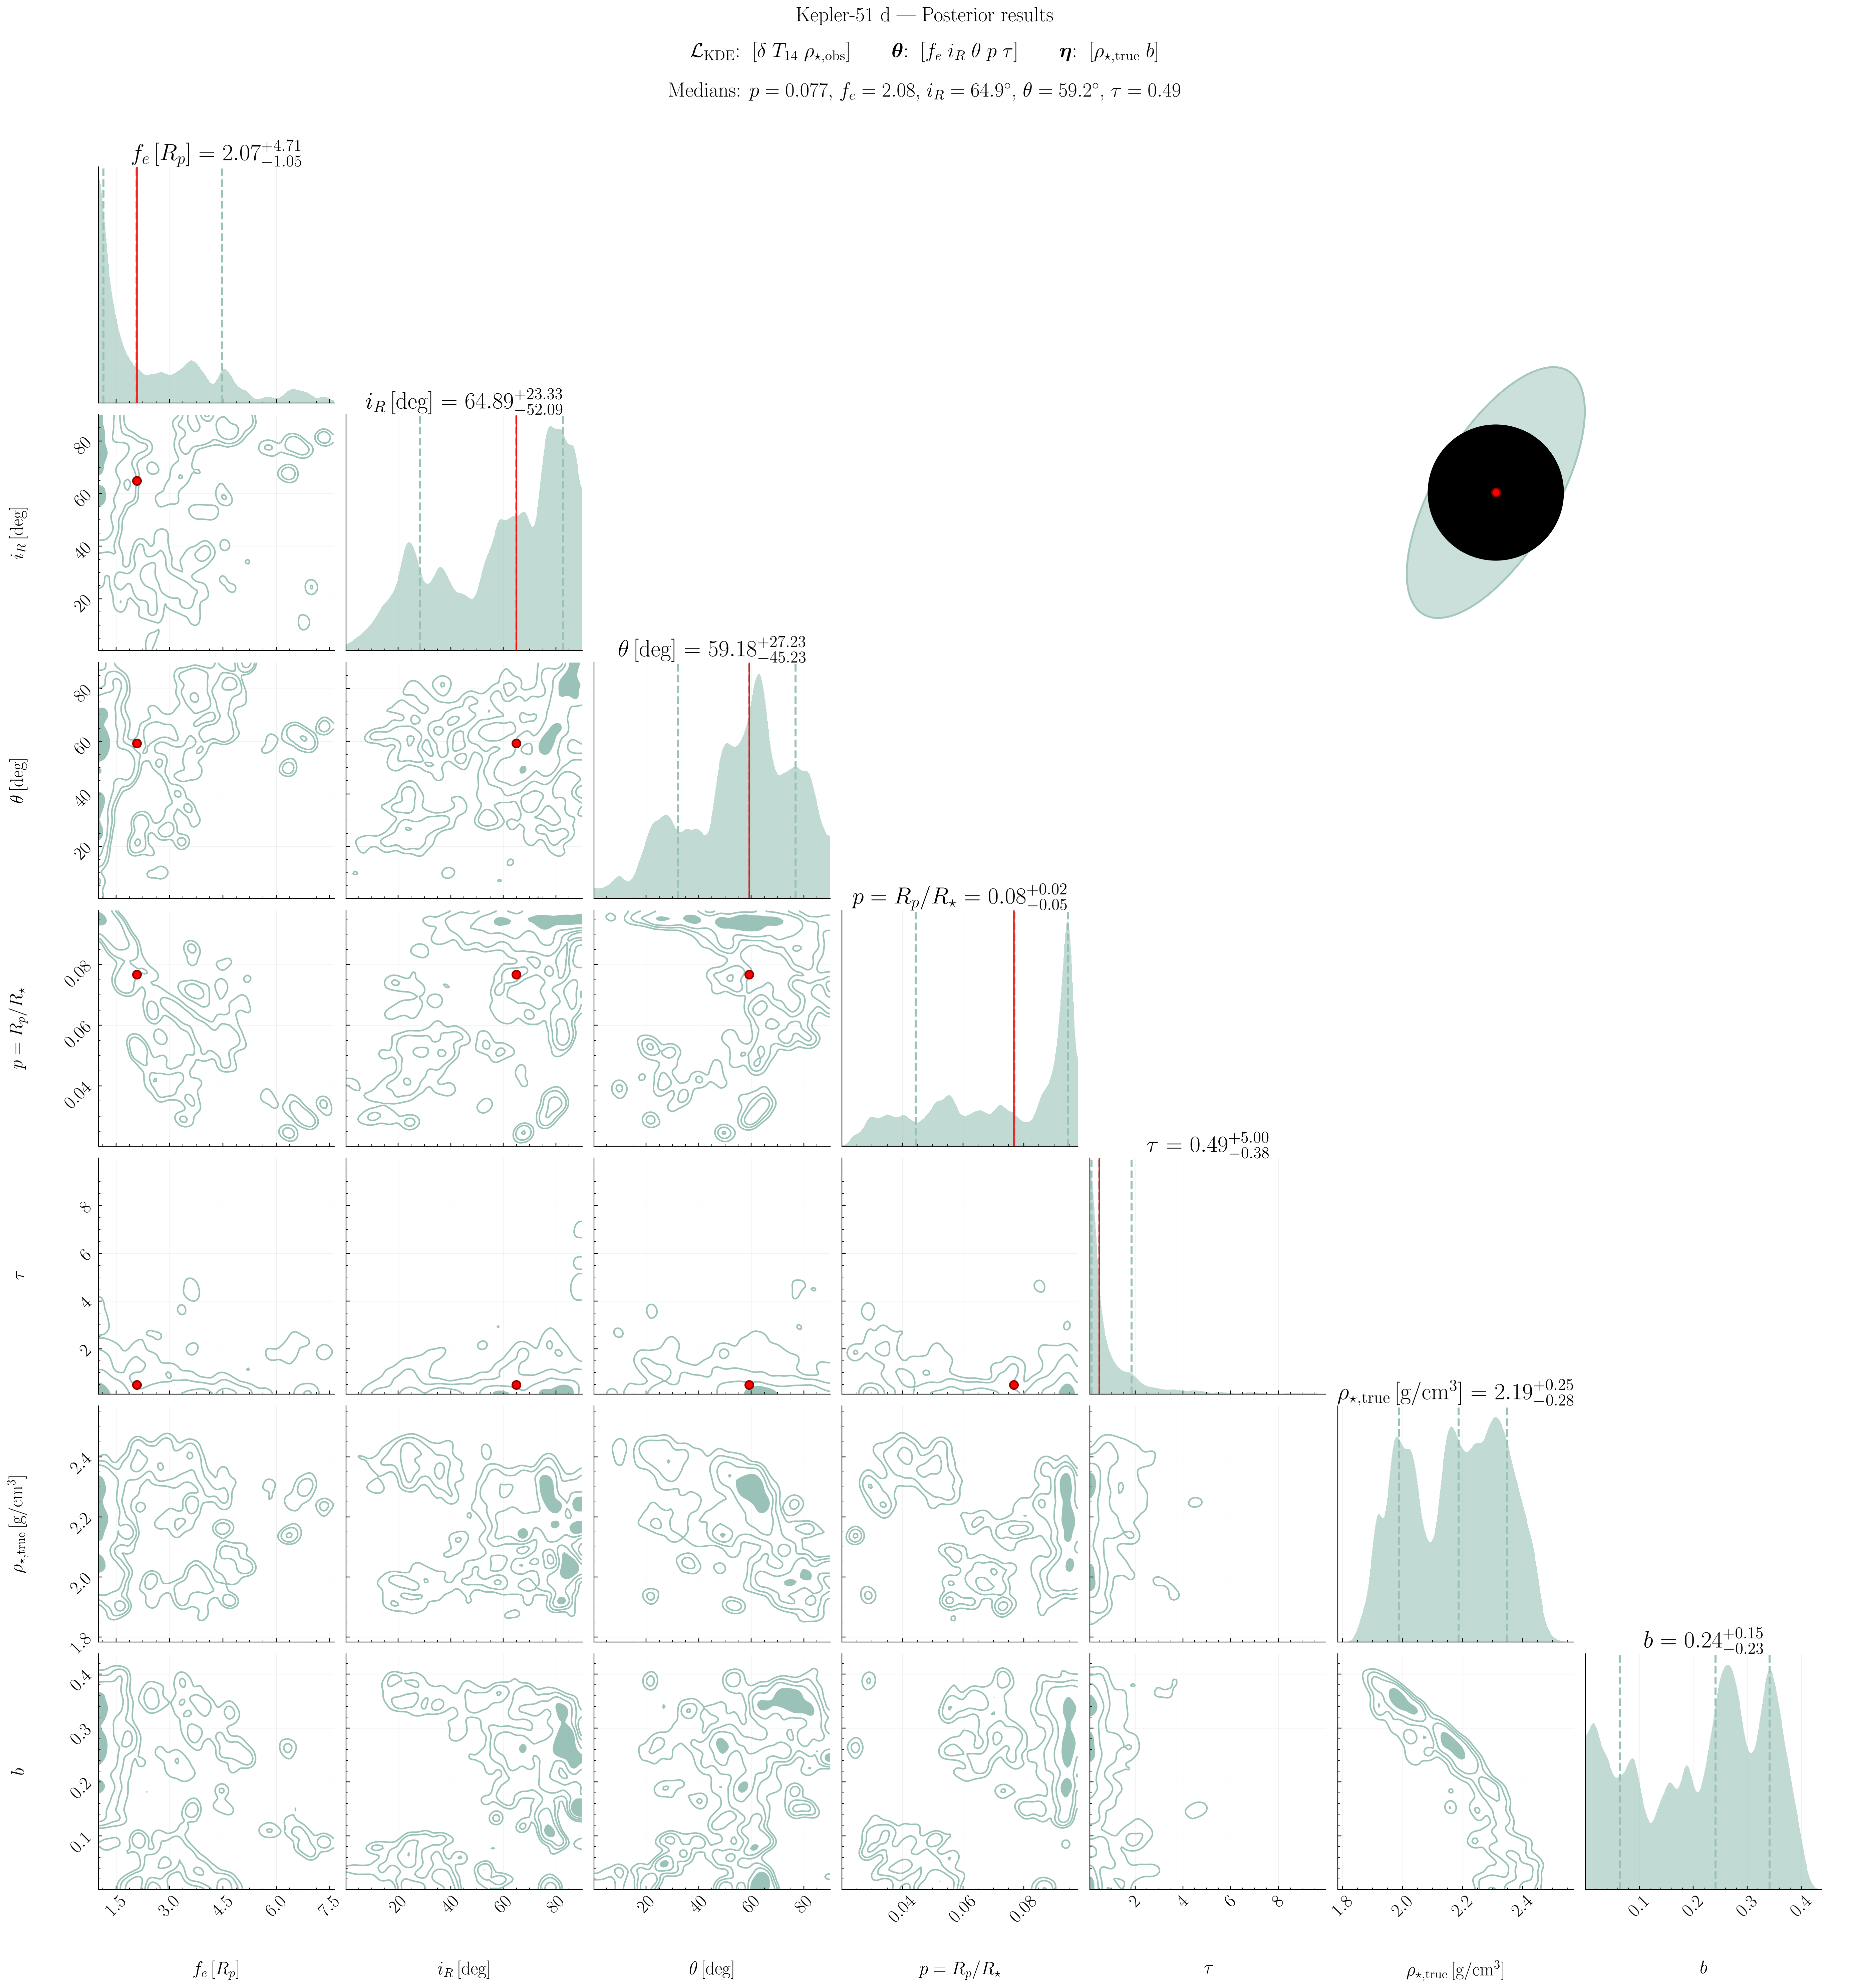

--- Corner Plot for Geotrans ---


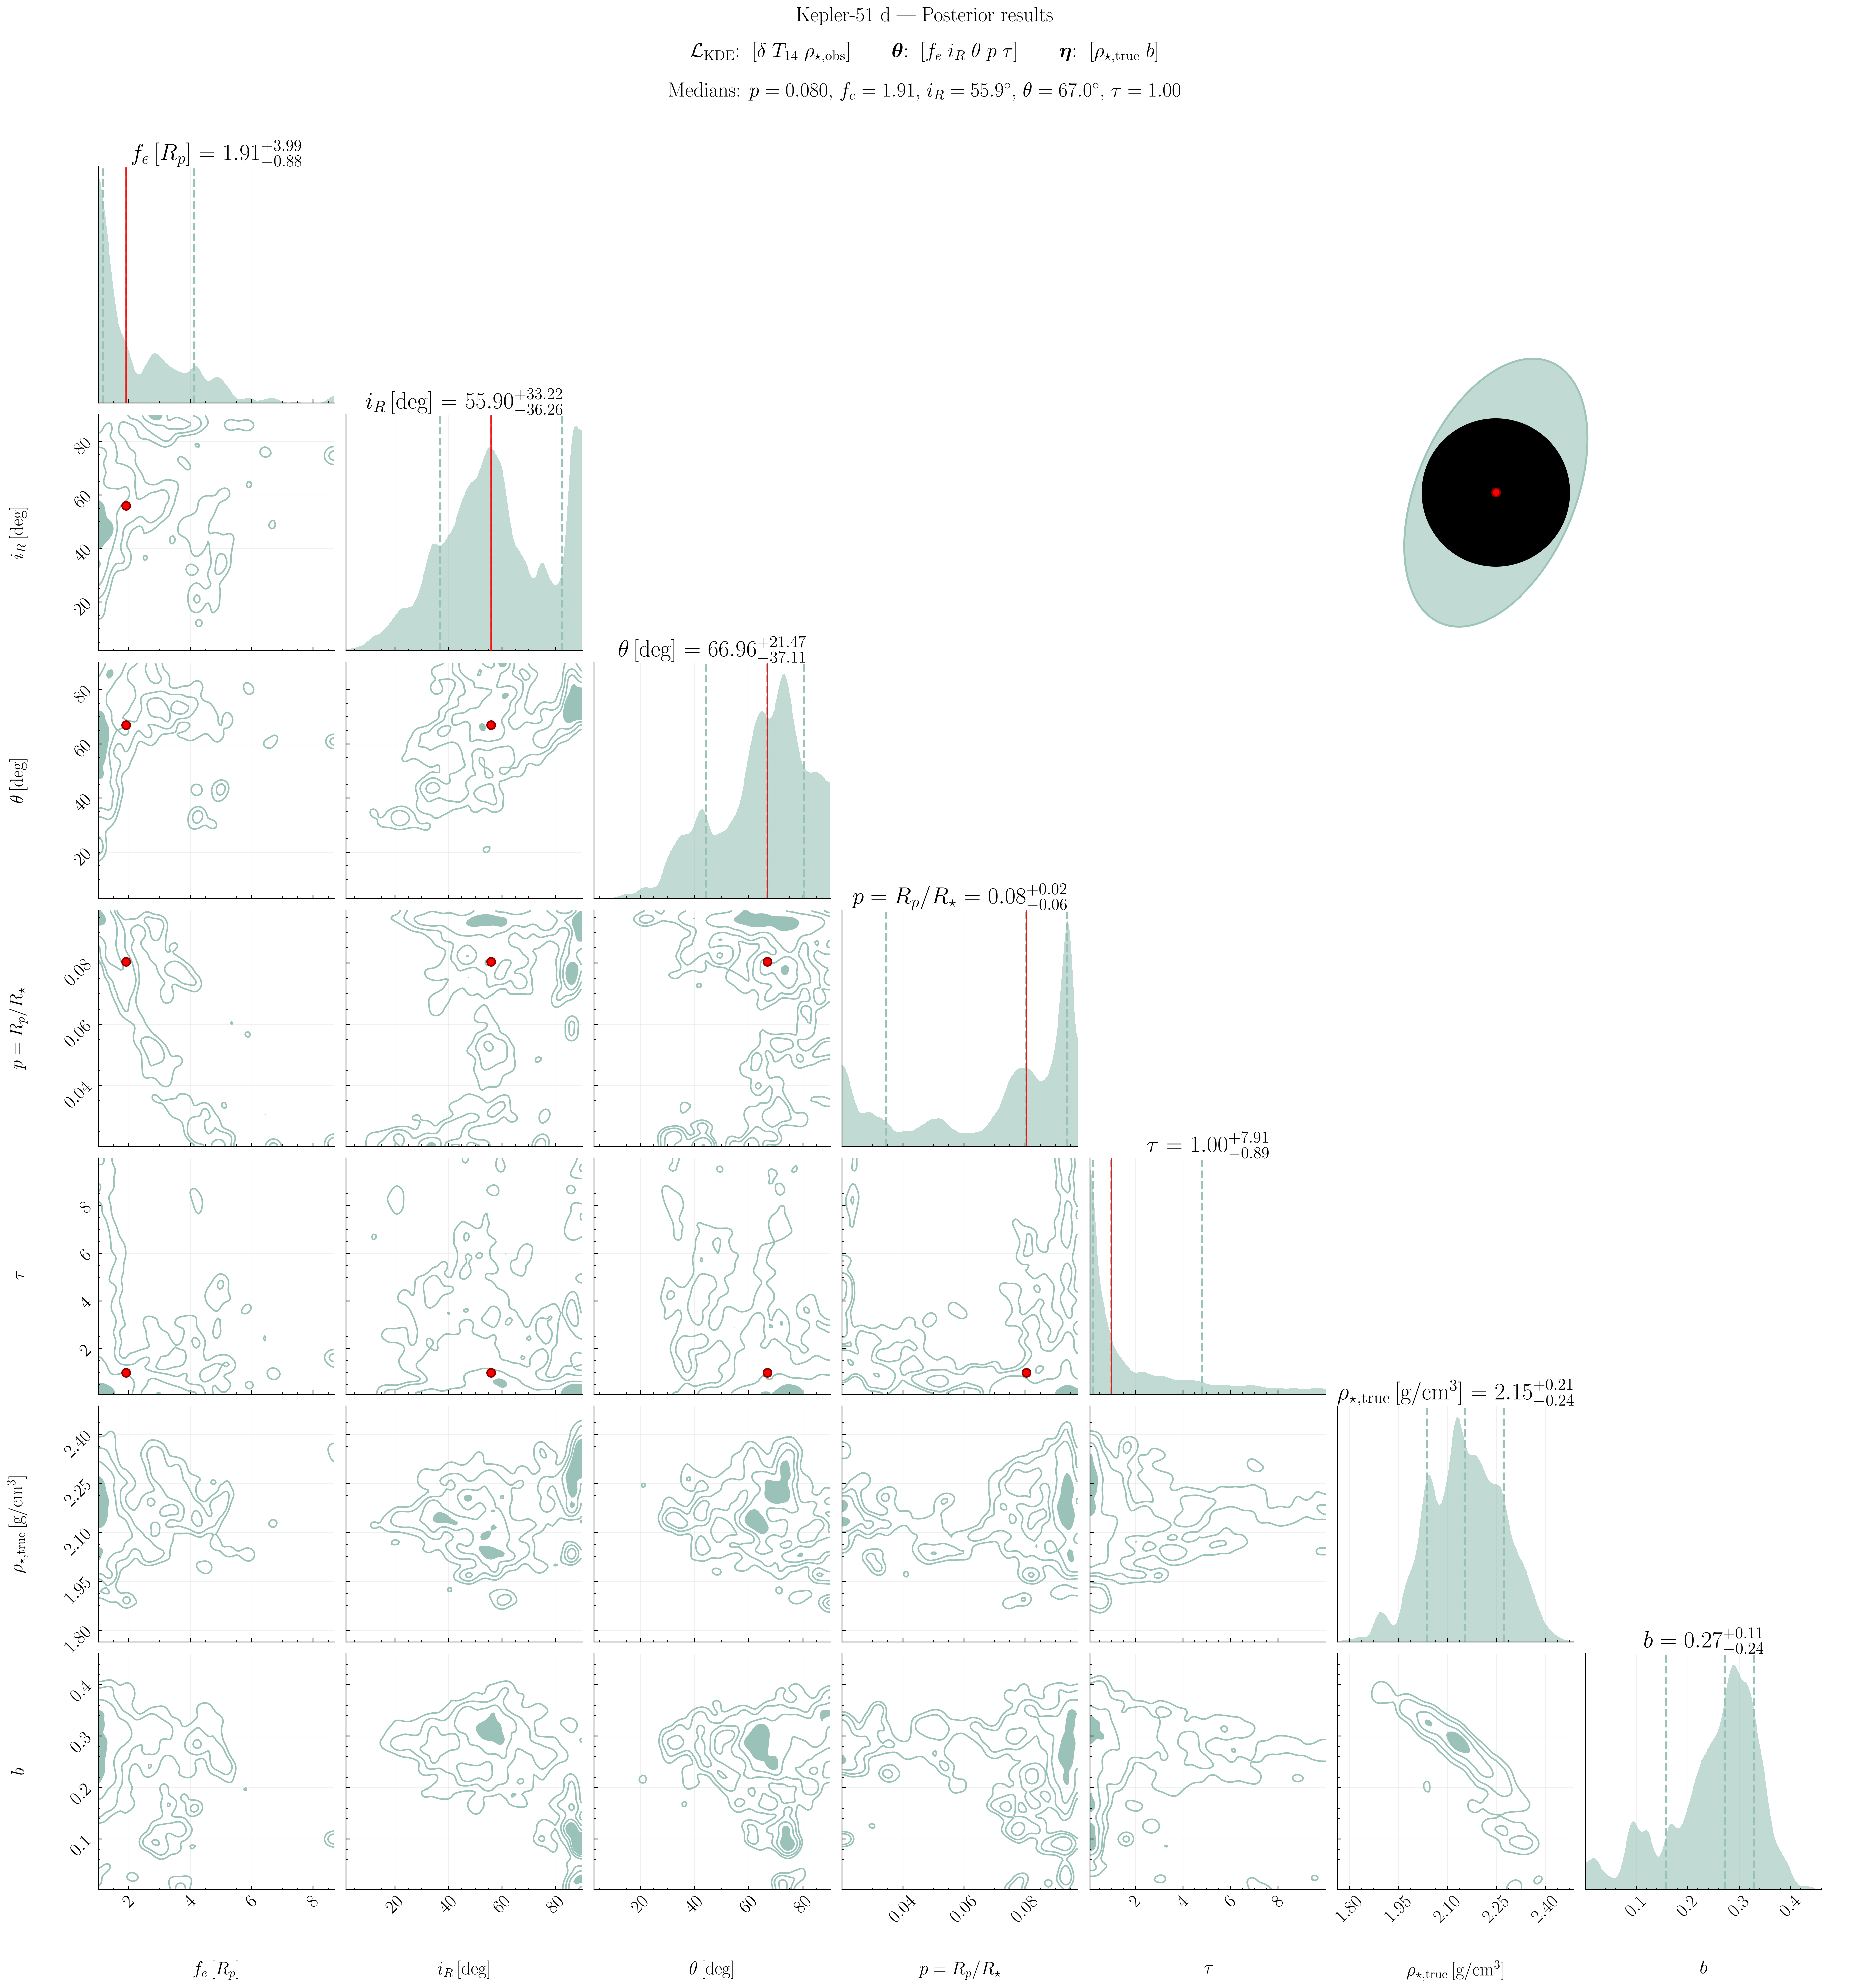

In [8]:
print("--- Corner Plot for Exorings ---")
fig_exo = plot.plot_results_panel_inset(run_exo)
plt.show()

print("--- Corner Plot for Geotrans ---")
fig_geo = plot.plot_results_panel_inset(run_geo)
plt.show()


--- PPC for Exorings ---


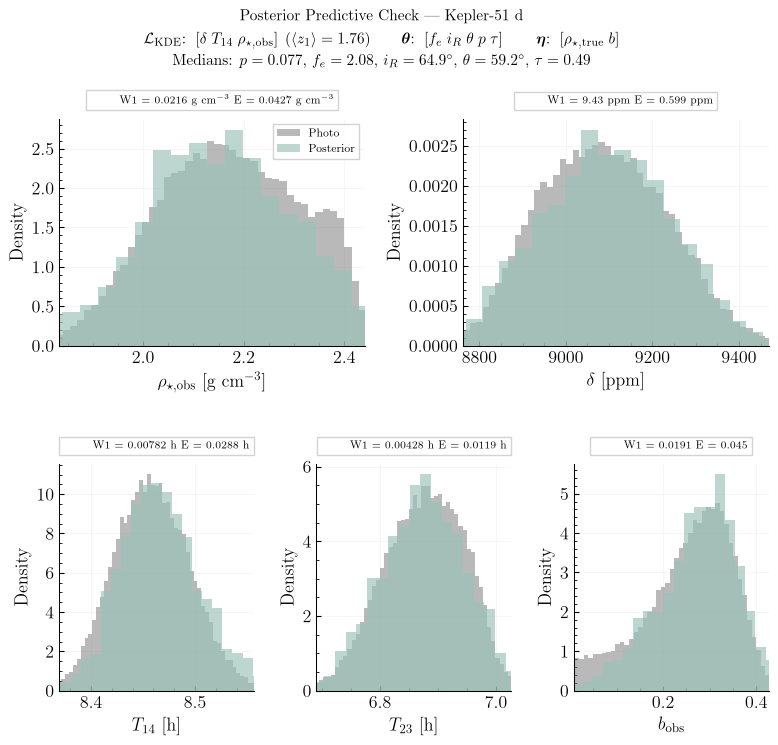

--- PPC for Geotrans ---


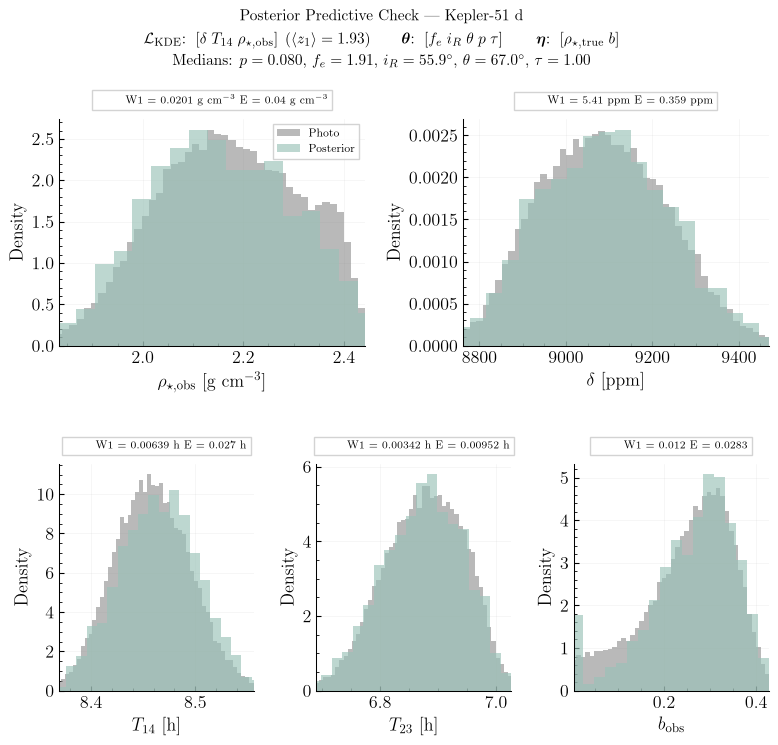

In [9]:
obs_keys = ["delta", "T14", "T23", "rho_obs", "b_obs"]

print("--- PPC for Exorings ---")
fig_ppc_exo, _ = plot.plot_ppc(run_exo, ttv, obs_keys=obs_keys)
plt.show()

print("--- PPC for Geotrans ---")
fig_ppc_geo, _ = plot.plot_ppc(run_geo, ttv, obs_keys=obs_keys)
plt.show()
